# Drosophila connectome → SONATA → Brian2

End-to-end example that:
1. Converts the `philshiu/Drosophila_brain_model` connectome to SONATA format (`nodes.h5`, `edges.h5`). Neuron parameters (`eq_th`, `eq_rst`, `rfc`, and the numeric per-neuron values) are stored in `dynamics_params` under a single model group `0` that every neuron references.
2. Specifies the stimulation protocol as a SONATA `simulation_config.json`.
3. Runs a single trial with the original `model.run_trial` and a single trial with a generic Brian2-SONATA wrapper (`brian2_sonata_runner.run_sonata_brian2_trial`).
4. Compares the spiking activity of the two trials.

The reference code lives at <https://github.com/philshiu/Drosophila_brain_model>. Either clone it next to this notebook or point `DROSOPHILA_REPO` below at an existing checkout.

## 1. Setup and imports

`brian2` is not a core dependency of obi-one — install it on demand.

In [1]:
import importlib
import subprocess
import sys

if importlib.util.find_spec('brian2') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'brian2'])

In [2]:
import json
import shutil
import subprocess
import sys
from pathlib import Path
from textwrap import dedent

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import brian2
from brian2 import Hz, mV, ms

HERE = Path.cwd()
sys.path.insert(0, str(HERE))
from brian2_sonata_runner import run_sonata_brian2_trial

## 2. Locate the reference repository

Clone `philshiu/Drosophila_brain_model` as a sibling directory if it isn't there yet. The large parquet (~100 MB) is fetched via git-LFS inside the repo's own setup; running a plain `git clone` is enough.

In [3]:
DROSOPHILA_REPO = HERE / 'Drosophila_brain_model'
if not DROSOPHILA_REPO.exists():
    subprocess.check_call([
        'git', 'clone', '--depth', '1',
        'https://github.com/philshiu/Drosophila_brain_model.git',
        str(DROSOPHILA_REPO),
    ])

PATH_COMP = DROSOPHILA_REPO / '2023_03_23_completeness_630_final.csv'
PATH_CON  = DROSOPHILA_REPO / '2023_03_23_connectivity_630_final.parquet'
assert PATH_COMP.exists(), f'Missing {PATH_COMP}'
assert PATH_CON.exists(), f'Missing {PATH_CON}'

sys.path.insert(0, str(DROSOPHILA_REPO))

Cloning into '/Users/james/Documents/obi/code/obi-main/obi-one/examples/J_drosophila_brian2_sonata/Drosophila_brain_model'...


## 3. Load the connectome

Row order in the completeness CSV defines the integer neuron index used by the rest of the pipeline.

In [4]:
df_comp = pd.read_csv(PATH_COMP, index_col=0)
df_con  = pd.read_parquet(PATH_CON)

flyid2i = {fid: i for i, fid in enumerate(df_comp.index)}
i2flyid = {i: fid for fid, i in flyid2i.items()}

N_NEURONS = len(df_comp)
N_EDGES   = len(df_con)
print(f'{N_NEURONS=}, {N_EDGES=}')
df_con.head(3)

N_NEURONS=127400, N_EDGES=14687178


,Presynaptic_ID,Postsynaptic_ID,Presynaptic_Index,Postsynaptic_Index,Connectivity,Excitatory,Excitatory x Connectivity
0,720575940596125868,720575940640198784,0,119081,1,1,1
1,720575940596125868,720575940605825666,0,2507,2,1,2
2,720575940596125868,720575940620159366,0,40129,10,1,10


## 4. Write `nodes.h5`

Layout:

```
/nodes/fly/
    node_type_id, node_group_id (all 0), node_group_index
    0/
        flywire_id                    int64[N]
        model_type, model_template    string[N]
        dynamics_params/
            v_0, v_rst, v_th          float64[N]   (volts, SI)
            t_mbr, tau, rfc           float64[N]   (seconds, SI)
            eqs, eq_th, eq_rst, method   scalar strings
```

Every neuron points to group `0`; a future heterogeneous circuit would add group `1`, `2`, … each with its own `dynamics_params`.

In [5]:
OUT_DIR = HERE / 'sonata_circuit'
OUT_DIR.mkdir(exist_ok=True)
NODES_PATH = OUT_DIR / 'nodes.h5'
EDGES_PATH = OUT_DIR / 'edges.h5'
NODE_POP = 'fly'
EDGE_POP = f'{NODE_POP}__{NODE_POP}__chemical'

# --- brian2 model parameters for group 0 (same values used by every neuron) ----
GROUP0_DYNAMICS = {
    'v_0':   -52e-3,    # volts
    'v_rst': -52e-3,
    'v_th':  -45e-3,
    't_mbr':  20e-3,    # seconds
    'tau':    5e-3,
    'rfc':    2.2e-3,
}
GROUP0_EQS = dedent(
    '''
    dv/dt = (v_0 - v + g) / t_mbr : volt (unless refractory)
    dg/dt = -g / tau : volt (unless refractory)
    v_0 : volt (constant)
    v_rst : volt (constant)
    v_th : volt (constant)
    t_mbr : second (constant)
    tau : second (constant)
    rfc : second (constant)
    '''
).strip()
GROUP0_EQ_TH  = 'v > v_th'
GROUP0_EQ_RST = 'v = v_rst; g = 0 * mV'
GROUP0_METHOD = 'linear'

if NODES_PATH.exists():
    NODES_PATH.unlink()

str_dt = h5py.string_dtype(encoding='utf-8')

def _str_array(value, n):
    return np.array([value] * n, dtype=object)

with h5py.File(NODES_PATH, 'w') as f:
    pop = f.create_group(f'nodes/{NODE_POP}')
    pop.create_dataset('node_type_id',     data=np.full(N_NEURONS, -1, dtype=np.int32))
    pop.create_dataset('node_group_id',    data=np.zeros(N_NEURONS, dtype=np.uint32))
    pop.create_dataset('node_group_index', data=np.arange(N_NEURONS, dtype=np.uint32))

    g0 = pop.create_group('0')
    g0.create_dataset('flywire_id',     data=np.asarray(df_comp.index.values, dtype=np.int64))
    g0.create_dataset('model_type',     data=_str_array('point_neuron',              N_NEURONS), dtype=str_dt)
    g0.create_dataset('model_template', data=_str_array('brian2:lif_alpha_group_0',  N_NEURONS), dtype=str_dt)

    dp = g0.create_group('dynamics_params')
    for key, val in GROUP0_DYNAMICS.items():
        dp.create_dataset(key, data=np.full(N_NEURONS, val, dtype=np.float64))
    dp.create_dataset('eqs',    data=GROUP0_EQS,    dtype=str_dt)
    dp.create_dataset('eq_th',  data=GROUP0_EQ_TH,  dtype=str_dt)
    dp.create_dataset('eq_rst', data=GROUP0_EQ_RST, dtype=str_dt)
    dp.create_dataset('method', data=GROUP0_METHOD, dtype=str_dt)

print(f'Wrote {NODES_PATH} ({NODES_PATH.stat().st_size/1e6:.1f} MB)')

Wrote /Users/james/Documents/obi/code/obi-main/obi-one/examples/J_drosophila_brian2_sonata/sonata_circuit/nodes.h5 (21.9 MB)


## 5. Write `edges.h5`

One edge population `fly__fly__chemical`, one edge group `0`. Per-edge weights are the product `Excitatory x Connectivity * w_syn` already expressed in volts, so the runner can assign them directly.

Source/target IDs are left 0-based (SONATA convention). `brainbuilder._write_indexes` lays down the `indices` groups so `libsonata`/`bluepysnap` can read the file.

In [6]:
from brainbuilder.utils.sonata.split_population import _write_indexes

W_SYN_VOLT = 0.275e-3   # 0.275 mV, free parameter from the reference model
T_DLY_SEC  = 1.8e-3     # 1.8 ms per-edge synaptic delay

src = df_con['Presynaptic_Index'].to_numpy(dtype=np.int64)
tgt = df_con['Postsynaptic_Index'].to_numpy(dtype=np.int64)
weights = df_con['Excitatory x Connectivity'].to_numpy(dtype=np.float64) * W_SYN_VOLT
delays  = np.full(N_EDGES, T_DLY_SEC, dtype=np.float64)

if EDGES_PATH.exists():
    EDGES_PATH.unlink()

with h5py.File(EDGES_PATH, 'w') as f:
    pop = f.create_group(f'edges/{EDGE_POP}')
    src_ds = pop.create_dataset('source_node_id', data=src)
    src_ds.attrs['node_population'] = NODE_POP
    tgt_ds = pop.create_dataset('target_node_id', data=tgt)
    tgt_ds.attrs['node_population'] = NODE_POP
    pop.create_dataset('edge_type_id',     data=np.full(N_EDGES, -1, dtype=np.int64))
    pop.create_dataset('edge_group_id',    data=np.zeros(N_EDGES, dtype=np.int64))
    pop.create_dataset('edge_group_index', data=np.arange(N_EDGES, dtype=np.uint64))

    g0 = pop.create_group('0')
    g0.create_dataset('syn_weight', data=weights)
    g0.create_dataset('delay',      data=delays)
    g0.create_dataset('on_pre', data='g += syn_weight', dtype=h5py.string_dtype(encoding='utf-8'))

_write_indexes(str(EDGES_PATH), EDGE_POP, source_node_count=N_NEURONS, target_node_count=N_NEURONS)
print(f'Wrote {EDGES_PATH} ({EDGES_PATH.stat().st_size/1e6:.1f} MB)')

Wrote /Users/james/Documents/obi/code/obi-main/obi-one/examples/J_drosophila_brian2_sonata/sonata_circuit/edges.h5 (1063.6 MB)


## 6. Write `circuit_config.json` and `node_sets.json`

In [7]:
neu_sugar = [
    720575940624963786, 720575940630233916, 720575940637568838, 720575940638202345,
    720575940617000768, 720575940630797113, 720575940632889389, 720575940621754367,
    720575940621502051, 720575940640649691, 720575940639332736, 720575940616885538,
    720575940639198653, 720575940620900446, 720575940617937543, 720575940632425919,
    720575940633143833, 720575940612670570, 720575940628853239, 720575940629176663,
    720575940611875570,
]
sugar_indices = [int(flyid2i[fid]) for fid in neu_sugar]

circuit_cfg = {
    'manifest': {'$NETWORK_DIR': '.'},
    'networks': {
        'nodes': [{
            'nodes_file': '$NETWORK_DIR/nodes.h5',
            'populations': {NODE_POP: {'type': 'point_neuron'}},
        }],
        'edges': [{
            'edges_file': '$NETWORK_DIR/edges.h5',
            'populations': {EDGE_POP: {'type': 'chemical'}},
        }],
    },
    'node_sets_file': '$NETWORK_DIR/node_sets.json',
}
(OUT_DIR / 'circuit_config.json').write_text(json.dumps(circuit_cfg, indent=2))

node_sets = {
    'All':           {'population': NODE_POP},
    'sugar_neurons': {'population': NODE_POP, 'node_id': sugar_indices},
}
(OUT_DIR / 'node_sets.json').write_text(json.dumps(node_sets, indent=2))
print('circuit_config.json + node_sets.json written')

circuit_config.json + node_sets.json written


## 7. Sanity-check the SONATA files with bluepysnap

In [8]:
import bluepysnap

snap = bluepysnap.Circuit(str(OUT_DIR / 'circuit_config.json'))
pop = snap.nodes[NODE_POP]
print(f'bluepysnap sees {pop.size} nodes, properties: {sorted(pop.property_names)}')
print(pop.get(properties=['flywire_id', 'model_type']).head())

epop = snap.edges[EDGE_POP]
print(f'bluepysnap sees {epop.size} edges')
print(epop.get(edge_ids=np.arange(3), properties=['@source_node', '@target_node', 'syn_weight', 'delay']))

bluepysnap sees 127400 nodes, properties: ['@dynamics:eq_rst', '@dynamics:eq_th', '@dynamics:eqs', '@dynamics:method', '@dynamics:rfc', '@dynamics:t_mbr', '@dynamics:tau', '@dynamics:v_0', '@dynamics:v_rst', '@dynamics:v_th', 'flywire_id', 'model_template', 'model_type']
                  flywire_id    model_type
node_ids                                  
0         720575940596125868  point_neuron
1         720575940597856265  point_neuron
2         720575940597944841  point_neuron
3         720575940598267657  point_neuron
4         720575940599333574  point_neuron
bluepysnap sees 14687178 edges
   @source_node  @target_node  syn_weight   delay
0             0        119081    0.000275  0.0018
1             0          2507    0.000550  0.0018
2             0         40129    0.002750  0.0018


## 8. Write `simulation_config.json`

The stimulus protocol from the reference model — a Poisson drive into the 21 sugar neurons at 150 Hz with a weight of `w_syn * f_poi = 0.275 mV * 250 = 68.75 mV` — is encoded in `inputs`. The `zero_refractory` flag tells the runner to clear `rfc` on the stimulated neurons to match the reference `poi()` behaviour.

In [9]:
T_RUN_MS     = 200.0    # length of one trial
SIM_DT_MS    = 0.1
RANDOM_SEED  = 42
POISSON_RATE = 150.0               # Hz
POISSON_W    = 0.275e-3 * 250.0    # volts (w_syn * f_poi)

sim_cfg = {
    'manifest': {'$BASE_DIR': '.'},
    'run': {'tstop': T_RUN_MS, 'dt': SIM_DT_MS, 'random_seed': RANDOM_SEED},
    'target_simulator': 'BRIAN2',
    'network': '$BASE_DIR/circuit_config.json',
    'node_sets_file': '$BASE_DIR/node_sets.json',
    'inputs': {
        'poisson_sugar': {
            'input_type': 'spikes',
            'module': 'poisson',
            'node_set': 'sugar_neurons',
            'rate': POISSON_RATE,
            'weight': POISSON_W,
            'target_var': 'v',
            'zero_refractory': True,
        }
    },
    'output': {'output_dir': './output'},
}
(OUT_DIR / 'simulation_config.json').write_text(json.dumps(sim_cfg, indent=2))
print('simulation_config.json written')

simulation_config.json written


## 9. Single trial with the original `model.run_trial`

Seed Brian2 explicitly so the trial is reproducible.

In [10]:
from model import default_params, run_trial

params = dict(default_params)
params['t_run'] = T_RUN_MS * ms
params['r_poi'] = POISSON_RATE * Hz

brian2.start_scope()
brian2.defaultclock.dt = SIM_DT_MS * ms
brian2.seed(RANDOM_SEED)

orig_spike_trains = run_trial(
    exc=sugar_indices,
    exc2=[],
    slnc=[],
    path_comp=PATH_COMP,
    path_con=PATH_CON,
    params=params,
)
print(f'original: {len(orig_spike_trains)} neurons fired, '
      f'{sum(len(v) for v in orig_spike_trains.values())} spikes total')

original: 353 neurons fired, 2764 spikes total


## 10. Single trial with the generic SONATA-Brian2 runner

In [11]:
sonata_result = run_sonata_brian2_trial(
    OUT_DIR / 'simulation_config.json',
    seed=RANDOM_SEED,
    progress=True,
)
sonata_spike_trains = sonata_result['spike_trains']
print(f'sonata: {len(sonata_spike_trains)} neurons fired, '
      f'{sum(len(v) for v in sonata_spike_trains.values())} spikes total')

Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 2s
sonata: 353 neurons fired, 2764 spikes total


## 11. Compare trials

Same seed, equivalent network construction, so the per-neuron spike counts and raster should line up tightly.

In [12]:
def to_count_vector(spk_trains, n):
    v = np.zeros(n, dtype=int)
    for idx, times in spk_trains.items():
        v[int(idx)] = len(times)
    return v

orig_counts   = to_count_vector(orig_spike_trains,   N_NEURONS)
sonata_counts = to_count_vector(sonata_spike_trains, N_NEURONS)

both_active = (orig_counts > 0) | (sonata_counts > 0)
n_active    = int(both_active.sum())
print(f'neurons that fired in either trial: {n_active}')
if n_active:
    r = np.corrcoef(orig_counts[both_active], sonata_counts[both_active])[0, 1]
    print(f'Pearson r of per-neuron spike counts: {r:.4f}')
    print(f'mean |Δcount|: {np.mean(np.abs(orig_counts - sonata_counts)):.3f}')
print(f'identical spike-count vectors: {np.array_equal(orig_counts, sonata_counts)}')

neurons that fired in either trial: 353
Pearson r of per-neuron spike counts: 1.0000
mean |Δcount|: 0.000
identical spike-count vectors: True


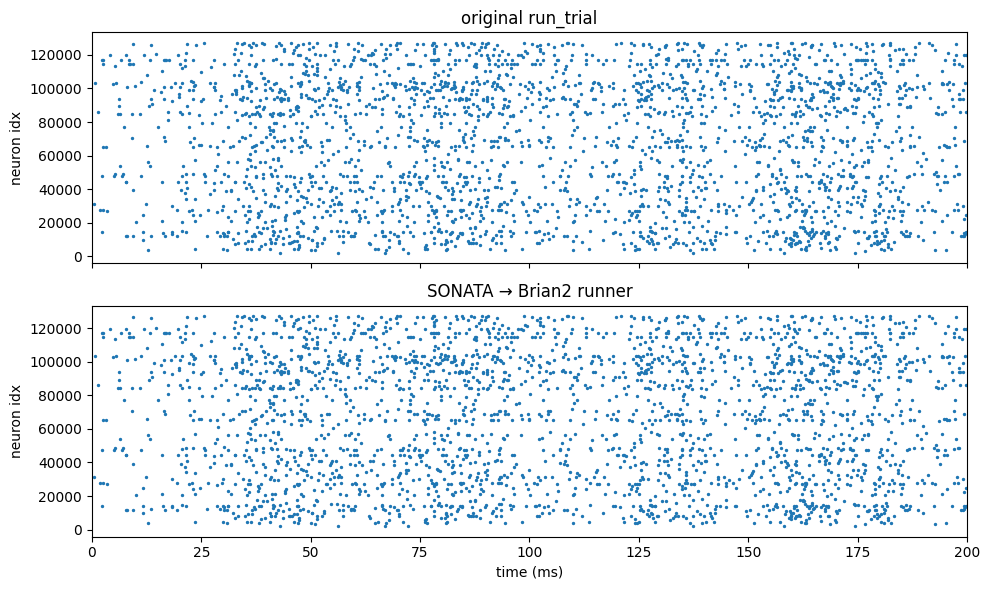

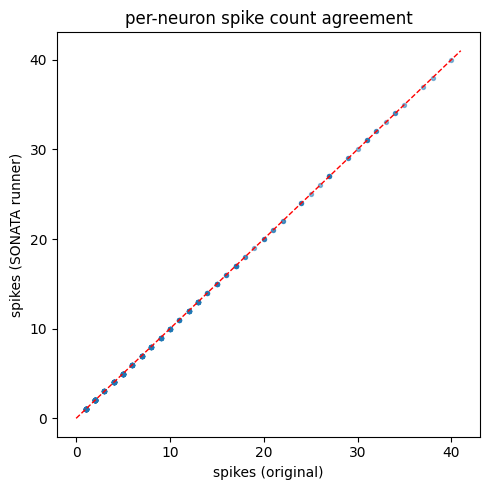

In [13]:
def raster_points(spk_trains):
    ts, ids = [], []
    for idx, times in spk_trains.items():
        t_ms = np.asarray(times) * 1000.0
        ts.extend(t_ms.tolist())
        ids.extend([int(idx)] * len(t_ms))
    return np.asarray(ts), np.asarray(ids)

fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True, sharey=True)
for ax, title, trains in [
    (axs[0], 'original run_trial',       orig_spike_trains),
    (axs[1], 'SONATA → Brian2 runner',   sonata_spike_trains),
]:
    t, n = raster_points(trains)
    ax.scatter(t, n, s=2)
    ax.set_title(title)
    ax.set_ylabel('neuron idx')
axs[1].set_xlabel('time (ms)')
axs[1].set_xlim(0, T_RUN_MS)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 5))
mask = both_active
ax.scatter(orig_counts[mask], sonata_counts[mask], s=8, alpha=0.5)
lim = max(orig_counts.max(), sonata_counts.max()) + 1
ax.plot([0, lim], [0, lim], 'r--', lw=1)
ax.set_xlabel('spikes (original)')
ax.set_ylabel('spikes (SONATA runner)')
ax.set_title('per-neuron spike count agreement')
plt.tight_layout()
plt.show()